# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

print("All libraries imported suuccessfully!")


All libraries imported suuccessfully!


# Load the DataSet

In [2]:
# Load California Housing Dataset
housing =fetch_california_housing()

#Convert to DataFrame
df = pd.DataFrame(housing.data, columns = housing.feature_names)

#Add Target column (house price)
df["Price"] = housing.target

print("Dataset loaded successfully")
print("Shape",df.shape)
df.head()



Dataset loaded successfully
Shape (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# First Look At Data

In [3]:
#First Look
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Stats:")
df.describe()


Shape: (20640, 9)

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

Basic Stats:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# EDA + CorrelationHeatmap

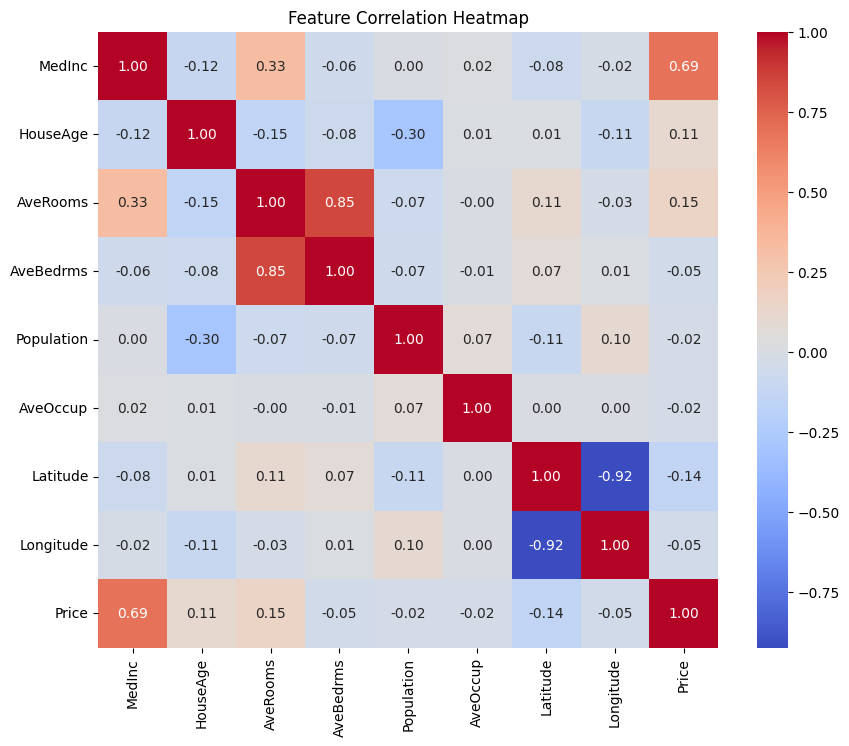

In [4]:
#EDA-Correlation Heatmap
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(), annot =True, cmap ="coolwarm", fmt =".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Visualization

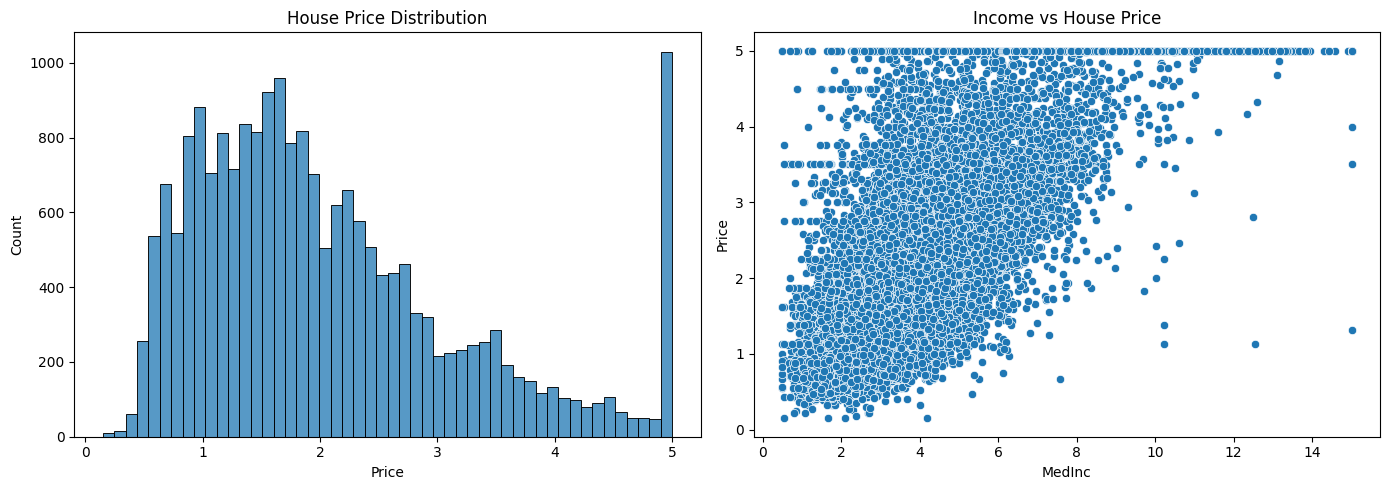

In [5]:
#Visualization
fig,axes = plt.subplots(1,2,figsize =(14,5))

#1. Price Distribution
sns.histplot(df["Price"],bins = 50, ax =axes[0])
axes[0].set_title("House Price Distribution")

#2. MedInc vs Price
sns.scatterplot(x ="MedInc", y="Price",data =df, ax =axes[1])
axes[1].set_title("Income vs House Price")

plt.tight_layout()
plt.show()


# Feature Engineering

In [10]:
#Feature Engineering
#Define X and Y
X =df.drop(columns = ["Price"])
Y = df["Price"]

#Split data
X_train,X_test, Y_train, Y_Test = train_test_split(X,Y, test_size =0.2,random_state = 42)

print("X Shape:", X.shape)
print("Y shape:", Y.shape)
print("Training size:", X_train.shape)
print("Testing size:",X_test.shape)


X Shape: (20640, 8)
Y shape: (20640,)
Training size: (16512, 8)
Testing size: (4128, 8)


# Build Linear Regression Model

In [22]:
# Build Linear Regression Model

#1. Create and Train Model
model = LinearRegression()
model.fit(X_train,Y_train)

#2. Make Predictions
y_pred = model.predict(X_test)

print("Model trained successfully!")
print("\nSample predictions vs Actual:")
for i in range(5):
  print(f"Predicted: {y_pred[i]:.2f}| Actual:{Y_Test.iloc[i]:.2f}")




Model trained successfully!

Sample predictions vs Actual:
Predicted: 0.72| Actual:0.48
Predicted: 1.76| Actual:0.46
Predicted: 2.71| Actual:5.00
Predicted: 2.84| Actual:2.19
Predicted: 2.60| Actual:2.78


# Evaluate the Model

In [23]:
#Evaluate Model
mae =mean_absolute_error(Y_Test, y_pred)
mse = mean_squared_error(Y_Test, y_pred )
rmse = mse**0.5
r2 = r2_score(Y_Test, y_pred)

print("Model Evaluation:")
print(f"MAE  (Mean Absolute Error): {mae:.2f}")
print(f"MSE  (Mean Squared Error):  {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")



Model Evaluation:
MAE  (Mean Absolute Error): 0.53
MSE  (Mean Squared Error):  0.56
RMSE (Root Mean Squared Error): 0.75
R2 Score: 0.58


In [24]:
# Conclusions
print("=" * 55)
print("HOUSE PRICE PREDICTION - CONCLUSIONS")
print("=" * 55)

print("\nDataset: California Housing")
print("Total Houses:", len(df))
print("Features Used:", X.shape[1])

print("\nModel Performance:")
print(f"MAE:      ${mae * 100000:.0f} average error")
print(f"RMSE:     ${rmse * 100000:.0f} average error")
print(f"R2 Score: {r2:.2f} (model explains 58% of price variation)")

print("\nKey Insights:")
print("- MedInc is strongest predictor (correlation 0.69)")
print("- Location (Latitude/Longitude) has small effect")
print("- HouseAge has very weak effect on price")
print("- Censored data above $500K affected model accuracy")

print("\nModel Used: Linear Regression")

HOUSE PRICE PREDICTION - CONCLUSIONS

Dataset: California Housing
Total Houses: 20640
Features Used: 8

Model Performance:
MAE:      $53320 average error
RMSE:     $74558 average error
R2 Score: 0.58 (model explains 58% of price variation)

Key Insights:
- MedInc is strongest predictor (correlation 0.69)
- Location (Latitude/Longitude) has small effect
- HouseAge has very weak effect on price
- Censored data above $500K affected model accuracy

Model Used: Linear Regression
